In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [4]:
df_train

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


In [5]:
df_test

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...
...,...,...,...
7595,1,Around the world,Ukrainian presidential candidate Viktor Yushch...
7596,2,Void is filled with Clement,With the supply of attractive pitching options...
7597,2,Martinez leaves bitter,Like Roger Clemens did almost exactly eight ye...
7598,3,5 of arthritis patients in Singapore take Bext...,SINGAPORE : Doctors in the United States have ...


In [6]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Class Index  120000 non-null  int64
 1   Title        120000 non-null  str  
 2   Description  120000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.7 MB


In [7]:
df_train['Class Index'].value_counts()

Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

In [8]:
df_test['Class Index'].value_counts()

Class Index
3    1900
4    1900
2    1900
1    1900
Name: count, dtype: int64

# Usunięcie znaków interpukcyjnych oraz zmiana wszystkich liter na małe w tytułach i opisach artykułów. Numery klas zaczynają się od 1, a trening wymaga, aby numery klas zaczynały się od 0, więc numery klas zostały pomniejszone o 1.

## Dane treningowe

In [9]:
# https://www.geeksforgeeks.org/python/python-remove-punctuation-from-string/
# https://www.geeksforgeeks.org/python/replace-characters-in-strings-in-pandas-dataframe/
df_train['Title'] = df_train['Title'].apply(
    lambda row: ''.join(filter(lambda char: char not in string.punctuation, row))
)

df_train['Description'] = df_train['Description'].apply(
    lambda row: ''.join(filter(lambda char: char not in string.punctuation, row))
)

df_train['Title'] = df_train['Title'].str.lower()
df_train['Description'] = df_train['Description'].str.lower()

df_train['Class Index'] = df_train['Class Index'] - 1

## Dane testowe

In [10]:
df_test['Title'] = df_test['Title'].apply(
    lambda row: ''.join(filter(lambda char: char not in string.punctuation, row))
)

df_test['Description'] = df_test['Description'].apply(
    lambda row: ''.join(filter(lambda char: char not in string.punctuation, row))
)

df_test['Title'] = df_test['Title'].str.lower()
df_test['Description'] = df_test['Description'].str.lower()

df_test['Class Index'] = df_test['Class Index'] - 1

# Utworzenie słownika, gdzie każdemu wyrazowi ze zbioru danych treningowych odpowiada określona liczba oraz \<PADDING> jako wartość 0, aby wszystkie wiadomości miały taką samą długość (model tego wymaga) oraz \<UNKNOWN WORDS> potencjalnie można przypisać nieznane słowo do tej kategorii.

In [11]:
max_length_title = df_train['Title'].str.split().str.len().max()
max_length_description = df_train['Description'].str.split().str.len().max()
unique_message_words = {word for text in df_train['Title'].tolist() + df_train['Description'].tolist() for word in text.split()}
word_to_idx = {'<PADDING>': 0, '<UNKNOWN WORDS>': 1} | {word: idx for idx, word in enumerate(unique_message_words, start=2)}

# Najdłuższy tytuł to 19 wyrazów, najdłuższy opis to 173 wyrazy, a wszystkie zebrane wyrazy jako tokeny (z danych treningowych) to 102159.

In [12]:
max_length_title, max_length_description, len(word_to_idx)

(np.int64(19), np.int64(173), 102159)

# Klasa służąca do odpowiedniego załadowania zbioru danych do modelu

## Inicjalizacja w init wymaganych zmiennych: tytułu artykułu, opisu artykułu, numerów klas (do jakiej klasy należy artykuł), zestaw tokenów (zebranych wcześniej wyrazów), najdłuższy tytuł oraz najdłuższy opis.
## Funkcja len zwraca długość zbioru danych (na podstawie ilości tytułów).
## W funkcji getitem przygotowywane są dane do treningu, walidacji, testów. Wyrazy zamieniane zostają na odpowiadające im liczby (tokeny), jeśli słowo nie widnieje w tokenach to zostaje przydzielona wartość 1 (\<UNKNOWN WORDS>) - dane testowe mogą zawierać słowa, które nie zostały zebrane w tokenach. Następnie wartości zostają zrównane o padding, aby każdy tytuł i każdy opis miał taką samą długość (każdy tytuł miał długość 19, a opis 173), czyli dodawane są wartości 0 na końcu łańcucha o odpowiednią długość. Ostatecznie funkcja zwraca: tytuł, opis, klasę dla określonego indeksu.

In [13]:
class CustomDataset(Dataset):
    def __init__(self, titles, descriptions, labels, tokens, max_length_title, max_length_description):
        self.titles = titles
        self.descriptions = descriptions
        self.labels = labels
        self.tokens = tokens
        self.max_length_title = max_length_title
        self.max_length_description = max_length_description

    def __len__(self):
        return len(self.titles)

    def __getitem__(self, idx):
        title = [self.tokens[word] if word in self.tokens else 1 for word in self.titles[idx].split()]
        title = title + np.zeros(self.max_length_title - len(title), dtype=int).tolist()
        description = [self.tokens[word] if word in self.tokens else 1 for word in self.descriptions[idx].split()]
        description = description + np.zeros(self.max_length_description - len(description), dtype=int).tolist()
        label = self.labels[idx]
        return torch.tensor(title, dtype=torch.long), torch.tensor(description, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# Konstrukcja modelu RNN
## 1. nn.Embedding - tworzy wektory słów. Długość wektora dla każdego słowa wynosi embed_size, czyli ustaloną wartość przy starcie treningu. Standardowa wartość to embed_size = 128. Wektory tworzone są dla każdego słowa, więc trzeba podać ilość wyrazów, czyli vocab_size. Liczby na początku tworzone są losowo w wektorach, a potem dostosowywane podczas backpropagation.
## 2. nn.RNN - czyta słowa po kolei i oblicza tym samym wagi, które mają posłużyć do odpowiedniego odgadywania klas. Używa wzoru h_t = tanh(W_x * x_t + W_h * h_{t-1} + b) -> x_t - wektor słowa z embeddingu; h_t - nowy wektor RNN; W_x, W_h, b - wagi uczone poprzez backpropagation.
## 3. nn.Linear - zwraca logity dla klas, czyli surowe wyniki dla wszystkich klas. Przyjmuje wartość hidden_size, czyli rozmiar stanu ukrytego dla RNN. Standardowa wartość to hidden_size = 128. W tym przypadku wartość ta jest mnożona przez 2, ponieważ są 2 różne ciągi znaków: tytuł i opis artykułu. Wyjście, czyli output_size to ilość możliwych klas (w tym wypadku 4).
# Funkcja forward:
## Funkcja forward używa opisanych technik do ustalenia odpowiedniej klasy. Tworzone są wektory dla tytułu i opisu, następnie wyciągany stan ukryty po ostatnim kroku, czyli ten stan, który uwzględnia wszystkie wyrazy (każdy stan tak jak we wzorze idzie po kolei po każdym wyrazie, a ostatni stan ukryty ma obliczone wartości z uwzględnieniem każdego słowa). Dzięki .squeeze(0) zostaje usunięty pierwszy wymiar, który ma długość 1. Następnie łączone są obliczone wektory RNN, aby za pomocą nn.Linear dostać logity, czyli surowe wyniki dla każdej klasy i zwrócić wynik. 

In [14]:
# https://www.geeksforgeeks.org/deep-learning/implementing-recurrent-neural-networks-in-pytorch/
class AGNewsRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(AGNewsRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size * 2, output_size)
        
    def forward(self, title, description):
        title_emb = self.embedding(title)
        _, h_title = self.rnn(title_emb)
        h_title = h_title.squeeze(0)

        description_emb = self.embedding(description)
        _, h_description = self.rnn(description_emb)
        h_description = h_description.squeeze(0)

        combined = torch.cat([h_title, h_description], dim=1)
        
        out = self.fc(combined)
        return out

# Podział zbioru danych na treningowy, walidacyjny, testowy oraz załadowanie danych do DataLoader

In [15]:
train = CustomDataset(
    titles=df_train['Title'].tolist(),
    descriptions=df_train['Description'].tolist(),
    labels=df_train['Class Index'].tolist(),
    tokens=word_to_idx,
    max_length_title=max_length_title,
    max_length_description=max_length_description
)
train, valid = random_split(train, [0.9, 0.1], generator=torch.Generator().manual_seed(42))
test = CustomDataset(
    titles=df_test['Title'].tolist(),
    descriptions=df_test['Description'].tolist(),
    labels=df_test['Class Index'].tolist(),
    tokens=word_to_idx,
    max_length_title=max_length_title,
    max_length_description=max_length_description
)

train_loader = DataLoader(train, batch_size=32, shuffle=True)
test_loader = DataLoader(test, batch_size=32, shuffle=False)
valid_loader = DataLoader(valid, batch_size=32, shuffle=False)

# Inicjalizacja wymaganych wartości dla modelu

In [16]:
vocab_size = len(word_to_idx)
embed_size = 128
hidden_size = 128
output_size = 4

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = AGNewsRNN(vocab_size, embed_size, hidden_size, output_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Trening modelu z walidacją oraz zapisem modelu oraz danych do plików

In [17]:
num_epochs = 100
min_valid_loss = np.inf

for epoch in range(num_epochs):
    train_loss = 0
    model.train()
    for titles, descriptions, labels in train_loader:
        # Trening
        if torch.cuda.is_available():
            titles, descriptions, labels = titles.to(device), descriptions.to(device), labels.to(device)
        
        outputs = model(titles, descriptions)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Walidacja
    valid_loss = 0
    correct = 0
    total = 0
    model.eval()
    for titles, descriptions, labels in valid_loader:
        if torch.cuda.is_available():
            titles, descriptions, labels = titles.to(device), descriptions.to(device), labels.to(device)

        outputs = model(titles, descriptions)
        loss = criterion(outputs, labels)
        valid_loss = loss.item() * titles.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    log_message = f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss/len(train_loader):.4f}, '
    log_message += f'Validation: {valid_loss/len(valid_loader)}, Validation Accuracy: {100 * correct/total:.2f}%.'
    print(log_message)
    with open('log_messages.txt', 'a', encoding='utf-8') as f:
        f.write(log_message + '\n')

    if min_valid_loss > valid_loss:
        log_message2 = f'Epoch [{epoch+1}/{num_epochs}], Validation Loss Decreased: {min_valid_loss:.6f} ---> {valid_loss:.6f}, Model Saved.'
        print(log_message2)
        with open('log_messages2.txt', 'a', encoding='utf-8') as f2:
            f2.write(log_message2 + '\n')
        min_valid_loss = valid_loss
        torch.save(model.state_dict(), 'RNN_AGNews_best_model.pth')

Epoch [1/100], Loss: 1.3886, Validation: 0.11741557820638021, Validation Accuracy: 24.60%.
Epoch [1/100], Validation Loss Decreased: inf ---> 44.030842, Model Saved.
Epoch [2/100], Loss: 1.3159, Validation: 0.10717437744140625, Validation Accuracy: 35.89%.
Epoch [2/100], Validation Loss Decreased: 44.030842 ---> 40.190392, Model Saved.
Epoch [3/100], Loss: 1.2035, Validation: 0.09262287394205729, Validation Accuracy: 44.03%.
Epoch [3/100], Validation Loss Decreased: 40.190392 ---> 34.733578, Model Saved.
Epoch [4/100], Loss: 1.0967, Validation: 0.08102599589029948, Validation Accuracy: 51.73%.
Epoch [4/100], Validation Loss Decreased: 34.733578 ---> 30.384748, Model Saved.
Epoch [5/100], Loss: 0.9777, Validation: 0.06785028076171876, Validation Accuracy: 54.53%.
Epoch [5/100], Validation Loss Decreased: 30.384748 ---> 25.443855, Model Saved.
Epoch [6/100], Loss: 0.9000, Validation: 0.06077940368652344, Validation Accuracy: 57.00%.
Epoch [6/100], Validation Loss Decreased: 25.443855 ---

# Testowanie wytrenowanego modelu

## Model osiągnął 84.09% dokładności, co pokazuje, że model potencjalnie osiągnął dobre wyniki, choć warto przetestować model innymi metodami, np. confusion matrix, aby sprawdzić czy nie faworyzuje danej klasy.

In [18]:
model = AGNewsRNN(vocab_size, embed_size, hidden_size, output_size).to(device)
model.load_state_dict(torch.load('RNN_AGNews_best_model.pth'))

y_pred = []

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for titles, descriptions, labels in test_loader:
        if torch.cuda.is_available():
            titles, descriptions, labels = titles.to(device), descriptions.to(device), labels.to(device)

        outputs = model(titles, descriptions)
        _, predicted = torch.max(outputs.data, 1)
        y_pred.extend(predicted.cpu().tolist())
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy: {100 * correct/total:.2f}%.')

Test Accuracy: 84.09%.


# Zebranie odpowiednich danych z pliku utworzonego podczas treningu w celu stworzenia wykresów.

In [19]:
training_information = []
with open('log_messages.txt') as f:
    for row in f.readlines():
        pattern = r'Epoch \[(\d+)/100\], Loss: ([\d.]+), Validation: ([\d.e+-]+), Validation Accuracy: ([\d.]+)%.'
        log_message_numbers = re.search(pattern, row)
        training_information.append(
            {
                'Epoch': int(log_message_numbers.group(1)),
                'Loss': float(log_message_numbers.group(2)),
                'Validation': float(log_message_numbers.group(3)),
                'Validation Accuracy': float(log_message_numbers.group(4)) / 100
            }
        )
training_information_pd = pd.DataFrame(training_information)
training_information_pd

,Epoch,Loss,Validation,Validation Accuracy
0,1,1.3886,0.117416,0.2460
1,2,1.3159,0.107174,0.3589
2,3,1.2035,0.092623,0.4403
3,4,1.0967,0.081026,0.5173
4,5,0.9777,0.067850,0.5453
...,...,...,...,...
95,96,0.0789,0.063983,0.8167
96,97,0.0768,0.069952,0.8053
97,98,0.0870,0.080219,0.8163
98,99,0.0715,0.070581,0.8112


# Wykres Epoch vs Loss oraz Epoch vs Validation Accuracy pokazują, że trening wyglądał dość stabilnie z małymi 2 skokami, które potem zostały ustabilizowane. Ustawienie mniejszego learning rate sprawiło, że trening pozostał stabilny, gdzie wyższa wartość learning rate czyniło trening mniej stabilnym. Wykres przedstawiający Macierz Pomyłek (Confusion Matrix) pokazuje, że wytrenowany model radzi sobie dość dobrze z rozpoznawaniem klas. W przypadku niezbalansowanych danych (w tym przypadku dane są zbalansowane) dokładność modelu mogłaby dać wysoką wartość, a model mógłby klasyfikować każdy przypadek jako jedna klasa. Macierz Pomyłek pokazuje, że model dość dobrze klasyfikuje każdą klasę, ale widać też, że modelowi zdarza się popełniać błędy.

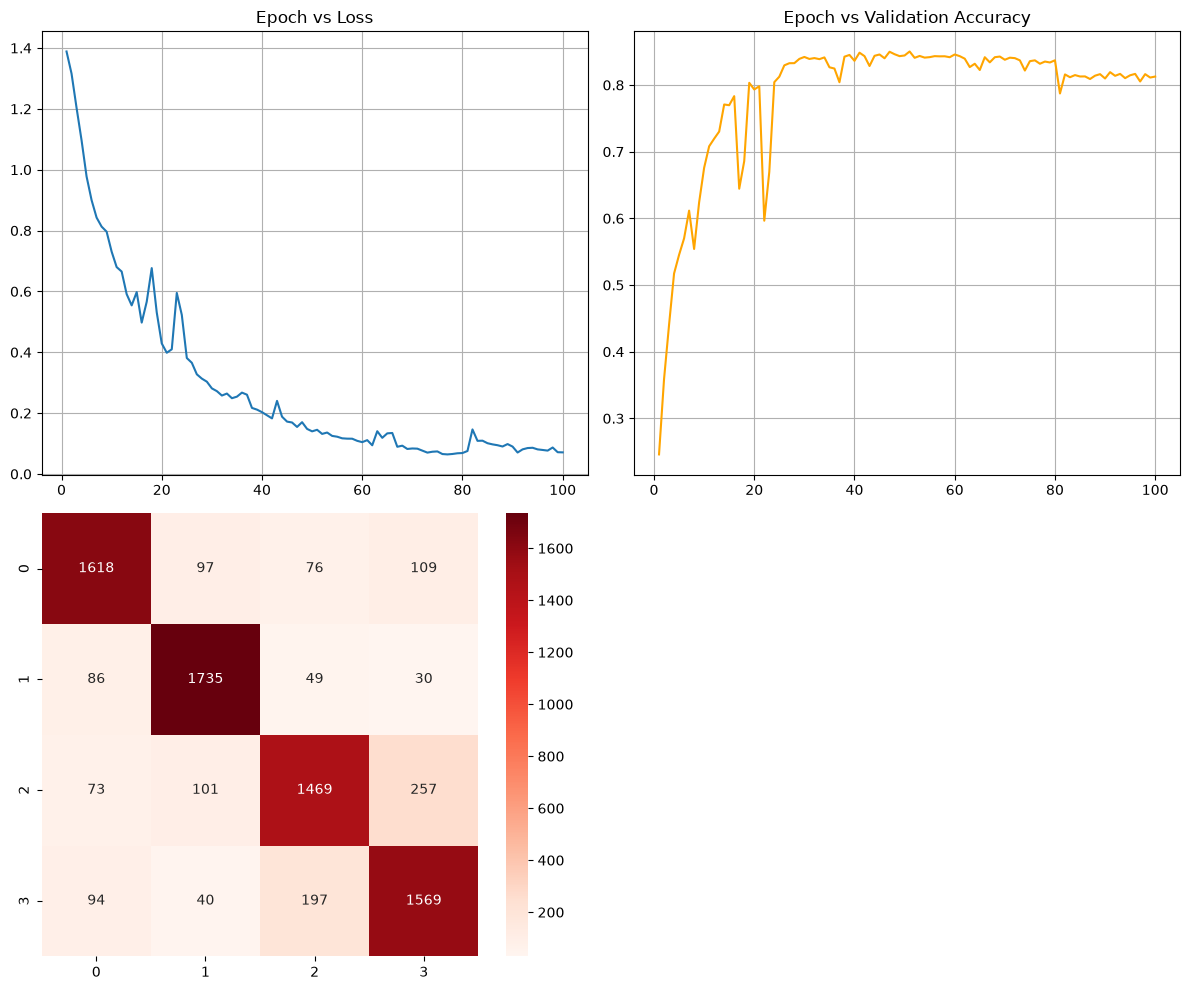

In [20]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].plot(training_information_pd['Epoch'], training_information_pd['Loss'])
ax[0, 0].set_title('Epoch vs Loss')
ax[0, 0].grid()

ax[0, 1].plot(training_information_pd['Epoch'], training_information_pd['Validation Accuracy'], color='orange')
ax[0, 1].set_title('Epoch vs Validation Accuracy')
ax[0, 1].grid()

sns.heatmap(confusion_matrix(df_test['Class Index'], y_pred), annot=True, fmt='d', cmap='Reds', ax=ax[1, 0])

ax[1, 1].remove()

plt.tight_layout()
plt.show()